In [1]:
%matplotlib ipympl
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import cmap

import scipy.ndimage

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "figure.constrained_layout.use": True,
})

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()
seq_cmap = cmap.Colormap('cmasher:tropical').to_mpl()
STATE_NAMES = ["continuous", "fragmented", "stationary"]

In [ ]:
mouse_id        = "107b"
data_dir        = INTERIM_DIR / mouse_id

sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
hd_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")
virtual_hds      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "virtual_hd.npz")
states          = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "virtual_states.npz")

nrem            = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])

### Compute preferred angle of HD cells

In [6]:
tcs = nap.compute_tuning_curves(hd_units, head_direction, bins=360, fs=1000, feature_names=['hd'])
tcs.values = scipy.ndimage.gaussian_filter1d(tcs.values, sigma=1, axis=1, mode="wrap")

pref_angle = tcs.idxmax(dim='hd').to_numpy().squeeze()
hd_order = np.argsort(pref_angle)

### Visualize

In [12]:
offset = 5
start, end = 22000, 23000
idx = np.where((nrem.start > start) & (nrem.start < end))[0] # 40, 73
ep = nrem[idx][1]
ep

  index    start    end
      0    22080  22134
shape: (1, 2), time unit: sec.

In [24]:
ep = nrem.intersect(session[session['state'] == 'homecage'])[62]
print(ep)

  index    start    end  state
      0    28006  28078  homecage
shape: (1, 2), time unit: sec.


In [25]:
hd_spikes = hd_units.restrict(ep)
turn_spikes = turn_units.restrict(ep)
virtual_hd = virtual_hds.restrict(ep)
state = states.restrict(ep)
cont_ep = state['continuous'].threshold(0.5).time_support
# cont_ep = cont_ep.merge_close_intervals(10, time_units='ms')
# cont_ep = cont_ep.drop_short_intervals(10, time_units='ms')

pop_vector = turn_spikes.count(bin_size=0.001).sum(axis=1)
pop_vector = pop_vector / 0.001
pop_vector = pop_vector.smooth(std=0.05)


turn_units_ids = np.array(turn_units.keys())
turn_units_ids = turn_units_ids[np.argsort([turn_units['turn_index'][n].item() for n in turn_units.keys()])]

hd_unit_ids = np.array(hd_spikes.keys())
hd_unit_ids = hd_unit_ids[np.argsort([pref_angle[n].item() for n in hd_unit_ids])]

Text(0.5, 0.98, 'Mouse 107b - NREM epoch (28006.0s : 28078.0s)')

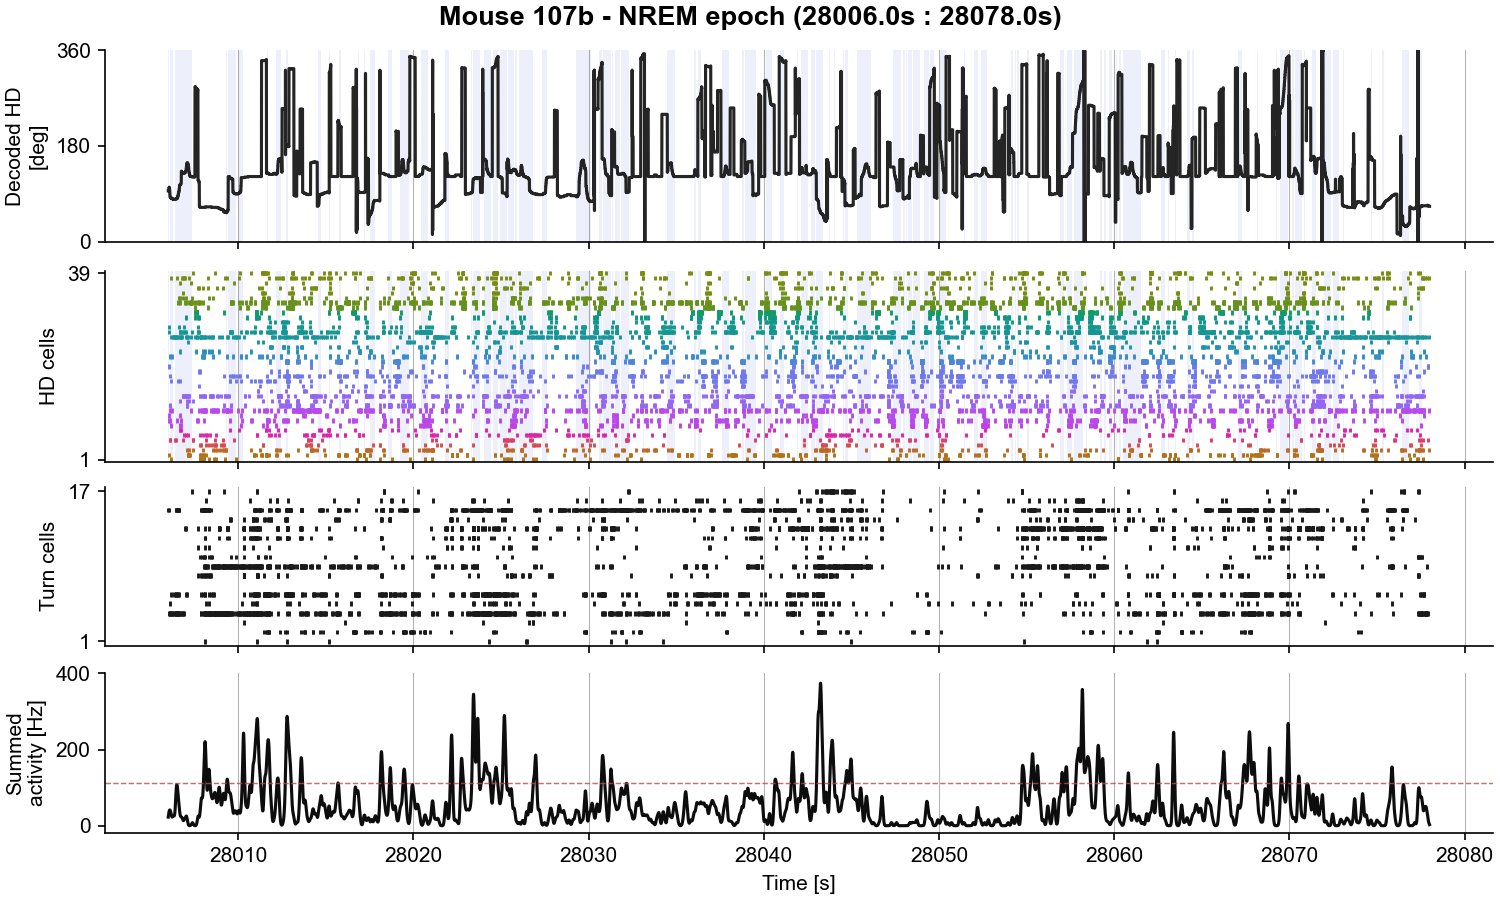

In [26]:
f, ax = plt.subplots(
    4, 1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.2, 1, 1]},
)
shade_color = "#6C7FD8"
threshold_color = "#B94A48"

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    a.grid(axis="x", color="0.4", linewidth=0.5, alpha=0.5, zorder=0)
    # a.set_axisbelow(True)

# Virtual HD trace only
ax[0].plot(
    virtual_hd,
    color="0.05",
    alpha=0.9,
    linewidth=1.5,
)
ax[0].set_ylabel("Decoded HD\n[deg]")
ax[0].set_ylim(0, 360)
ax[0].set_yticks([0, 180, 360])

for row, uid in enumerate(hd_unit_ids, start=1):
    pa = pref_angle[uid].item()
    ax[1].eventplot(
        hd_spikes[uid].index,
        lineoffsets=row,
        linelengths=0.9,
        linewidths=1.4,
        colors=[cyclic_cmap(pa / 360)],
        alpha=1,
    )

ax[1].set_ylabel("HD cells")
ax[1].set_ylim(0.5, len(hd_unit_ids) + 0.5)
ax[1].set_yticks([1, len(hd_unit_ids)])

# Shared continuous-state shading
for cep in cont_ep:
    for a in ax[:2]:
        a.axvspan(
            cep.start.item(),
            cep.end.item(),
            color=shade_color,
            alpha=0.12,
            linewidth=0,
            zorder=0,
        )


# Turn-cell raster
for row, uid in enumerate(turn_units_ids, start=1):
    ax[2].eventplot(
        turn_spikes[uid].index,
        lineoffsets=row,
        linelengths=0.5,
        linewidths=1.4,
        colors="0.10",
        alpha=1,
    )

ax[2].set_ylabel("Turn cells")
ax[2].set_ylim(0.5, len(turn_units) + 0.5)
ax[2].set_yticks([1, len(turn_units)])

# Population activity
ax[3].plot(pop_vector, color="0.05", linewidth=1.5)
ax[3].axhline(
    pop_vector.mean() + pop_vector.std(),
    color=threshold_color,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
)
ax[3].set_ylabel("Summed\nactivity [Hz]")
ax[3].set_xlabel("Time [s]")
ax[3].set_yticks([0, 200, 400])

f.suptitle(
    f"Mouse {mouse_id} - NREM epoch ({ep.start[0]:.1f}s : {ep.end[-1]:.1f}s)",
    fontsize=13,
    fontweight="bold",
)

# plt.savefig(save_dir / "snapshot_nrem1.png")

In [27]:
plt.savefig('nrem02.svg', format='svg', dpi=320)
plt.savefig('nrem02.png', format='png', dpi=320)